In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.options.display.max_columns=False
load_dotenv()

train_df = pd.read_csv(os.getenv('train_csv_path'))
test_df = pd.read_csv(os.getenv('test_csv_path'))

In [3]:
train_df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [4]:
train_df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [4]:
train_df.shape

(159571, 8)

In [5]:
test_df.shape

(153164, 2)

In [6]:
test_df.sample(5)

,id,comment_text
75505,7dd5641c99caa797,== i'm blocked!!!!!!!!!!!!!!!!!!!!!!!!!! ==
112655,bc020d5a74757d08,You have been blocked for 2 weeks for continui...
96500,a0fda24e54fcc8fa,== Palin's SAT scores? == \n\n An interesting ...
18873,1fc2d9b693e025af,""" \n\n ::: We usually differentiate between OW..."
98253,a3f02eafc9074c93,== dont be a homo == \n\n yyou fagget go die j...


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            153164 non-null  object
 1   comment_text  153164 non-null  object
dtypes: object(2)
memory usage: 2.3+ MB


In [9]:
train_df.nunique()

id               159571
comment_text     159571
toxic                 2
severe_toxic          2
obscene               2
threat                2
insult                2
identity_hate         2
dtype: int64

EDA

In [10]:
train_df.isnull().sum()
test_df.isnull().sum()

id              0
comment_text    0
dtype: int64

In [11]:
train_df.duplicated().sum()
test_df.duplicated().sum()

np.int64(0)

In [12]:
labels = [ "toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
label_counts = train_df[labels].sum()
label_counts

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

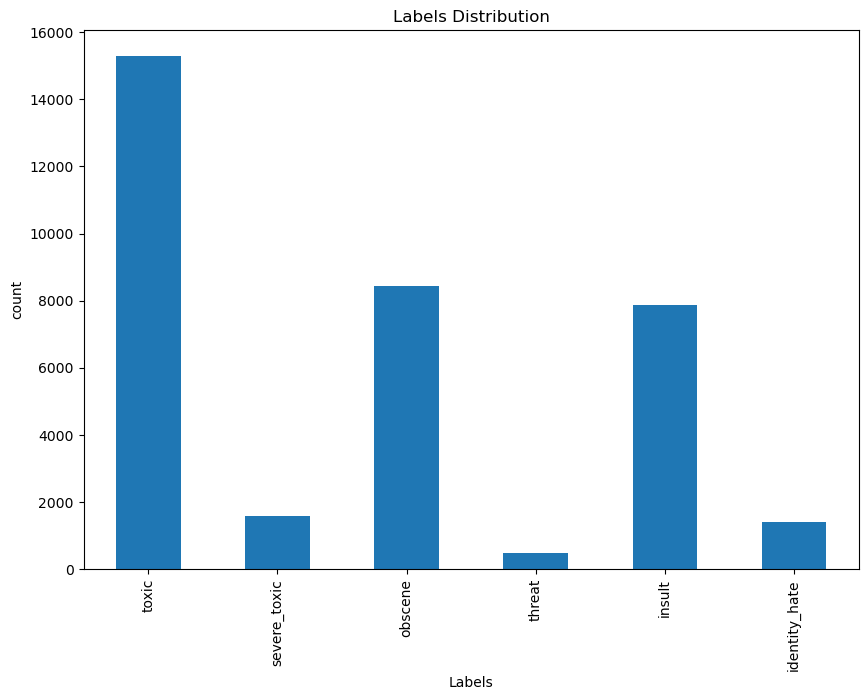

In [13]:
plt.figure(figsize=(10,7))
label_counts.plot(kind='bar')
plt.title("Labels Distribution")
plt.xlabel("Labels")
plt.ylabel('count')
plt.show()

1. To lower
2. remove \n \t
3. remove urls
4. remove multi spaces
5. remove email ids
6. remove html tags
7. ip addresses
8. numbers
9. .com .org ....
10. symbols == ***
11. spelling mistakes
13. emojis
14. stopwords
15. lemmatization

In [53]:
def to_lowercase(text):
    return text.lower()

In [66]:
def remove_html(text):
    text = html.unescape(text)
    text = text.lower()
    text = re.sub(r'<.*?>',' ',text)

    return text

In [58]:
def remove_urls(text):
    text = re.sub(r'((https?://|www\.)\S+|\b[\w.-]+\.[a-z]{2,}\b)',' <url> ',text,flags=re.IGNORECASE)
    return text

In [59]:
def remove_mails(text):
    return re.sub(r'\S+@\S+', ' <mail> ', text)

In [60]:
def remove_ips(text):
    return re.sub(r'\b(?:\d{1,3}\.){3}\d{1,3}\b', ' <ip> ', text)

In [61]:
def replace_Sntr(text):
    text = text.replace('\n', ' ')
    text = text.replace('\t', ' ')
    text = text.replace('\r', ' ')

    return text

In [62]:
def replace_num(text):
    return re.sub(r'\d+', ' <num> ', text)

In [63]:
def pun_and_spaces(text):
    text = re.sub(r'([!?.,:;"\'])\1+', r'\1', text)
    text = re.sub(r'^["\']+|["\']+$', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [71]:
def do_all(text):
    return(pun_and_spaces(replace_num(replace_Sntr(remove_ips(remove_mails(remove_urls(remove_html(to_lowercase(text)))))))))